# Brain Age Prediction with brainageR


**Author:** Monika Doerig

**Date:** 19 May 2026

**License:**
<div style="margin-top: 10px;">
    <a href="https://opensource.org/licenses/MIT" target="_blank" style="color: #0066cc;">
        <i class="fas fa-balance-scale"></i> MIT License
    </a>
</div>


**Note:** This notebook uses neuroimaging tools from Neurocontainers; those tools retain their original licenses. Please see <a href="https://neurodesk.org/overview/how-to-cite-us/" target="_blank" style="color: #0066cc;">Neurodesk citation guidelines</a> for details.

**Use of AI:** This notebook was generated with assistance from *Anthropic's Claude (via Claude Code)* across several iterations and then revised by the author. The author reviewed the final content and takes responsibility for it.

### Citation and Resources

#### Tools included in this workflow

**brainageR**

Per the brainageR maintainer, there is no single primary journal article for the software; instead, we cite the works that have used it:

- Clausen, A. N., Fercho, K. A., Monsour, M., Disner, S., Salminen, L., Haswell, C. C., … Morey, R. A. (2022). Assessment of brain age in posttraumatic stress disorder: Findings from the ENIGMA PTSD and brain age working groups. *Brain and Behavior*, 12(1), e2413. [https://doi.org/10.1002/brb3.2413](https://doi.org/10.1002/brb3.2413)
- Hobday, H., Cole, J. H., Stanyard, R. A., Daws, R. E., Giampietro, V., O'Daly, O., … Váša, F. (2022). Tissue volume estimation and age prediction using rapid structural brain scans. *Scientific Reports*, 12(1), 12005. [https://doi.org/10.1038/s41598-022-14904-5](https://doi.org/10.1038/s41598-022-14904-5)
- Biondo, F., Jewell, A., Pritchard, M., Aarsland, D., Steves, C. J., Mueller, C., & Cole, J. H. (2022). Brain-age is associated with progression to dementia in memory clinic patients. *NeuroImage: Clinical*, 36, 103175. [https://doi.org/10.1016/j.nicl.2022.103175](https://doi.org/10.1016/j.nicl.2022.103175)

Software:
- James Cole. (2019). james-cole/brainageR: brainageR v2.1 (2.1). Zenodo. [https://doi.org/10.5281/zenodo.3476365](https://doi.org/10.5281/zenodo.3476365)
- Source code: [james-cole/brainageR](https://github.com/james-cole/brainageR) 

**R / kernlab** (does most of the heavy lifting — Gaussian Process regression)

- Karatzoglou, A., Smola, A., Hornik, K., & Zeileis, A. (2004). kernlab — An S4 Package for Kernel Methods in R. *Journal of Statistical Software*, 11(9). [https://doi.org/10.18637/jss.v011.i09](https://doi.org/10.18637/jss.v011.i09) (see also [CRAN citation page](https://cran.r-project.org/web/packages/kernlab/citation.html)).

**SPM12** (used internally for segmentation and DARTEL normalisation)

- Friston, K. J., et al. (2007). *Statistical Parametric Mapping: The Analysis of Functional Brain Images.* Elsevier / Academic Press. [Online book](https://www.fil.ion.ucl.ac.uk/spm/doc/books/spm/Statistical_Parametric_Mapping_The_Analysis_of_Functional_Brain_Images.pdf)

#### Dataset

- Snoek, L., van der Miesen, M. M., Beemsterboer, T., van der Leij, A., Eigenhuis, A., & Steven Scholte, H. (2021). The Amsterdam Open MRI Collection, a set of multimodal MRI datasets for individual difference analyses. *Scientific Data*, 8(1), 85. [https://doi.org/10.1038/s41597-021-00870-6](https://doi.org/10.1038/s41597-021-00870-6) — AOMIC PIOP2 (OpenNeuro `ds002790`), CC0 license.


## 1. What is brain age?

Healthy brains change with age in fairly predictable ways — gray-matter volume shrinks, ventricles enlarge, white-matter signal shifts. A machine-learning model trained on many healthy MRIs can *guess a person's age* from a single T1 scan, purely based on these structural patterns.

The interesting quantity is not the guess itself, but the **brain-age gap**:

$$\text{brain-age gap} = \text{predicted age} - \text{chronological age}$$

- **Gap ≈ 0** → brain looks typical for the person's real age.
- **Gap > 0** → "older-looking" brain. In research cohorts, positive gaps have been associated with dementia risk, cardiovascular disease, and earlier mortality.
- **Gap < 0** → "younger-looking" brain.

### How brainageR works under the hood

1. **SPM12 segments** the T1 into gray matter, white matter, and CSF probability maps, and normalises them to MNI space using **DARTEL** (a diffeomorphic registration algorithm built into SPM12).
2. **PCA** reduces the dimensionality of the concatenated tissue-map features.
3. A **Gaussian Process regression** model — trained on 3,377 healthy adults (kernlab package in R) — predicts age from the PCA components. Reported test performance: *r* = 0.97 with chronological age, mean absolute error ≈ 3.9 years.

:::{important}                     
**Why use a model with ~3.9 year MAE as a biomarker?** Brain-age research generally focuses not on the absolute predicted age, but on the **distribution of residuals** (`predicted − chronological`) across groups. In healthy training data those residuals are approximately mean-zero noise. Some published studies have reported that residuals shift systematically when
the model is applied to other cohorts — for example, [Biondo et al. (2022)](https://doi.org/10.1016/j.nicl.2022.103175) report that each additional year of brain-age gap was associated with a ~3% increased risk of progression to dementia in memory clinic patients (HR 1.03, 95% CI [1.02, 1.04]). The magnitude and direction of any shift varies between studies and depends on the model version, training distribution, and scanner/sequence used, so brain-age findings are typically interpreted as **population-level effects, not per-subject diagnostic information**.
:::

### What we'll do in this notebook

We'll run brainageR on a real BIDS-formatted T1 from the **AOMIC PIOP2** open dataset (OpenNeuro `ds002790`). The dataset documents each participant's chronological age in `participants.tsv`, so we can compute a meaningful **brain-age gap**. These are the steps:

1. Load the `brainager/2.1.0` module and inspect its CLI.
2. Pull one healthy subject's T1 from AOMIC PIOP2 via DataLad, and read their chronological age from `participants.tsv`.
3. Run the full brainageR pipeline (segment + predict) in one command.
4. Compute the **brain-age gap** (predicted − chronological) and interpret it against the model's documented MAE.
5. Visually QC the tissue segmentation.

## 2. Load software and import python libraries

We pin `brainager/2.1.0` explicitly so the notebook is reproducible. This single module brings SPM12, R, and the brainageR scripts on PATH.

In [1]:
import module
await module.load('brainager/2.1.0')
await module.list()

['brainager/2.1.0']

`nilearn`, `nibabel`, and `pandas` — used below for visualisation, NIfTI I/O, and reading the participants TSV are not in the Neurodesk base image, so we install them here.

In [2]:
%%capture
!pip install nilearn==0.13.1 nibabel==5.4.2 pandas==2.3.3

In [3]:
import subprocess
from pathlib import Path

import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import plotting

## 3. Discover the tool's interface

Before running any unfamiliar tool, look at its `--help`. brainageR ships two scripts:

- `brainager_segment.py` — the **main entry point**. Despite the name, it runs *both* segmentation and prediction.
- `predict_age.py` — the prediction-only step. Called internally by `brainager_segment.py`.

In [4]:
!brainager_segment.py --help

usage: brainager_segment.py [-h] [--delete-temp] t1 [outdir]

BrainageR segmentation + prediction wrapper

positional arguments:
  t1             Input T1 image (.nii or .nii.gz)
  outdir         Output directory (default: script dir)

optional arguments:
  -h, --help     show this help message and exit
  --delete-temp  Delete temporary folder (default: keep)


In [20]:
! predict_age.py --help

usage: predict_age.py [-h] [--subjname SUBJNAME] tempdir

Run brainageR prediction on segmented images

positional arguments:
  tempdir              Sandbox directory with smwc* files

optional arguments:
  -h, --help           show this help message and exit
  --subjname SUBJNAME  Postfix for smwc1/2/3 images (default: T1w.nii)


## 4. Data preparation — fetch one AOMIC PIOP2 subject

[AOMIC PIOP2](https://openneuro.org/datasets/ds002790) (Snoek et al. 2021) is a CC0-licensed dataset of 98 healthy young adults scanned on a 3T Philips Achieva — well within brainageR's training distribution. We DataLad-install the dataset and fetch a **single subject's T1w**.

We then read the dataset's `participants.tsv` to get that subject's chronological age, which we'll need for computing the brain-age gap.

In [5]:
# Working directory for this run.
workdir = Path('brainageR')
workdir.mkdir(exist_ok=True)
print('Output workdir:', workdir.resolve())

Output workdir: /home/jovyan/Git_repositories/neurodeskedu/books/examples/structural_imaging/brainageR


In [8]:
%%bash
cd brainageR
[ -d ds002790 ] || datalad install https://github.com/OpenNeuroDatasets/ds002790.git
cd ds002790
datalad get participants.tsv sub-0001/anat/sub-0001_T1w.nii.gz
ls -lh sub-0001/anat/*_T1w.nii.gz participants.tsv

[INFO] Attempting a clone into /home/jovyan/Git_repositories/neurodeskedu/books/examples/structural_imaging/brainageR/ds002790 
[INFO] Attempting to clone from https://github.com/OpenNeuroDatasets/ds002790.git to /home/jovyan/Git_repositories/neurodeskedu/books/examples/structural_imaging/brainageR/ds002790 
[INFO] Start enumerating objects 
[INFO] Start counting objects 
[INFO] Start receiving objects 
[INFO] Start resolving deltas 
[INFO] Completed clone attempts for Dataset(/home/jovyan/Git_repositories/neurodeskedu/books/examples/structural_imaging/brainageR/ds002790) 
[INFO] Remote origin not usable by git-annex; setting annex-ignore 
[INFO] https://github.com/OpenNeuroDatasets/ds002790.git/config download failed: Not Found 


install(ok): /home/jovyan/Git_repositories/neurodeskedu/books/examples/structural_imaging/brainageR/ds002790 (dataset)
get(ok): sub-0001/anat/sub-0001_T1w.nii.gz (file) [from s3-PUBLIC...]
action summary:
  get (notneeded: 1, ok: 1)
-rw-r--r-- 1 jovyan users 13K May 14 06:08 participants.tsv
lrwxrwxrwx 1 jovyan users 140 May 14 06:08 sub-0001/anat/sub-0001_T1w.nii.gz -> ../../.git/annex/objects/kz/2q/MD5E-s6700721--4a2967b6a93eb821a564662577d8811d.nii.gz/MD5E-s6700721--4a2967b6a93eb821a564662577d8811d.nii.gz


In [9]:
# Identify the input T1 and read the subject's chronological age.
subject = 'sub-0001'
input_t1 = workdir / 'ds002790' / subject / 'anat' / f'{subject}_T1w.nii.gz'
assert input_t1.exists(), f'Input T1 missing: {input_t1}'

participants = pd.read_csv(workdir / 'ds002790' / 'participants.tsv', sep='\t')
row = participants[participants['participant_id'] == subject].iloc[0]
known_age = float(row['age'])
print(f'Input T1     : {input_t1}')
print(f'Subject      : {subject}')
print(f'Chronological age (from participants.tsv): {known_age:.1f} years')

Input T1     : brainageR/ds002790/sub-0001/anat/sub-0001_T1w.nii.gz
Subject      : sub-0001
Chronological age (from participants.tsv): 25.5 years


## 5. Visualise the input T1

Always look at your input. A quick three-plane view confirms the file loaded correctly and shows what brainageR will be working with.

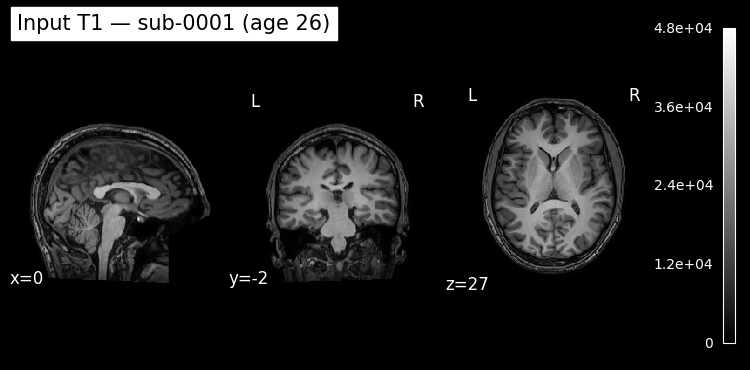

In [10]:
plotting.plot_anat(
    str(input_t1),
    title=f'Input T1 — {subject} (age {known_age:.0f})',
    display_mode='ortho',
    draw_cross=False,
    dim=-1,
)
plt.show()

## 6. Run brainageR (segmentation + prediction)

One command runs the full pipeline: `brainager_segment.py <T1> <outdir>`. Internally it:

1. Creates `<outdir>/<stem>/` (here: `brainageR_openneuro_demo/sub-0001_T1w/`) as a per-subject working folder.
2. Uncompresses the `.nii.gz` to `.nii` (SPM12 needs uncompressed NIfTI).
3. Runs **SPM12 NewSegment** to produce gray-matter (`c1*.nii`), white-matter (`c2*.nii`), and CSF (`c3*.nii`) probability maps, plus warped/normalised versions.
4. Invokes `predict_age.py` to feed those tissue maps into the trained Gaussian Process model and write `brainage_prediction.csv`.
5. Appends the result to a shared CSV at `<outdir>/brainage_prediction.csv` (useful when running many subjects).

:::{hint}
**Always pass the second positional argument (`outdir`).** On Neurodesk, `brainager_segment.py` runs inside a **read-only** Singularity container, so its default fallback (the script's install directory, `/opt/brainageR/`) isn't writable. Omitting `outdir` produces a `PermissionError`.
:::

Expect this to take **several minutes** — SPM12 standalone has slow MCR startup, then segmentation itself runs.

In [12]:
# brainager_segment.py <input T1>  <output dir>
#   input  : path to the BIDS T1w.
#   output : absolute host path, writable — all results land here
result = subprocess.run(
    ['brainager_segment.py', str(input_t1), str(workdir.resolve())],
    capture_output=True, text=True,
)

print('return code:', result.returncode)
print('--- stdout (tail) ---')
print('\n'.join(result.stdout.splitlines()[-15:]))
if result.returncode != 0:
    print('--- stderr ---')
    print(result.stderr)

return code: 0
--- stdout (tail) ---
[1] "loading nifti data Thu May 14 06:14:00 2026"
[1]      1 615541
[1] "loading regression model Thu May 14 06:14:15 2026"
[1] "saving new results Thu May 14 06:14:15 2026"
[DEBUG] PATH=/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/opt/spm12:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/opt/brainageR
[DEBUG] which Rscript=/usr/bin/Rscript
[DEBUG] which rscript=None
[INFO] Running: /usr/bin/Rscript /opt/brainageR/predict_new_data_gm_wm_csf.R /opt/brainageR /home/jovyan/Git_repositories/neurodeskedu/books/examples/structural_imaging/brainageR/sub-0001_T1w/smwc1sub-0001_T1w.nii /home/jovyan/Git_repositories/neurodeskedu/books/examples/structural_imaging/brainageR/sub-0001_T1w/smwc2sub-0001_T1w.nii /home/jovyan/Git_repositories/neurodeskedu/books/examples/structural_imaging/brainageR/sub-0001_T1w/smwc3sub-0001_T1w.nii /opt/brainageR/GPR_model_gm_wm_csf.RData /home/jovyan/Git_repositories/neurodeskedu/books/examples/struc

In [13]:
# Inspect what brainageR produced in the per-subject folder.
stem = input_t1.name.removesuffix('.nii.gz')
seg_dir = workdir / stem
for f in sorted(seg_dir.iterdir()):
    print(f.name)

brainage_prediction.csv
brainager_batch.m
c1sub-0001_T1w.nii
c2sub-0001_T1w.nii
c3sub-0001_T1w.nii
rc1sub-0001_T1w.nii
rc2sub-0001_T1w.nii
rc3sub-0001_T1w.nii
smwc1sub-0001_T1w.nii
smwc2sub-0001_T1w.nii
smwc3sub-0001_T1w.nii
sub-0001_T1w.nii
sub-0001_T1w_seg8.mat
sub-0001_T1w_tissue_volumes.csv
u_rc1sub-0001_T1w.nii


## 7. Read the prediction and compute the brain-age gap

The CSV contains the predicted brain age plus the 95% prediction interval. Combined with the chronological age we read from `participants.tsv`, we can compute the **brain-age gap** — the quantity that actually carries research signal in brain-age studies.

In [14]:
pred_csv = seg_dir / 'brainage_prediction.csv'
df_pred = pd.read_csv(pred_csv)
df_pred

,File,brain.predicted_age,lower.CI,upper.CI
0,sub-0001_T1w,24.3643,23.4529,25.2757


In [23]:
predicted_age = float(df_pred['brain.predicted_age'].iloc[0])
lo = float(df_pred['lower.CI'].iloc[0])
hi = float(df_pred['upper.CI'].iloc[0])
gap = predicted_age - known_age

print(f'Chronological age      : {known_age:.1f} years')
print(f'Predicted brain age    : {predicted_age:.2f} years   (95% CI: [{lo:.2f}, {hi:.2f}])')
print(f'Brain-age gap          : {gap:+.2f} years')
print()

print()                                                                                                                                
print(f'For reference, the model reports MAE ≈ 3.9 years on healthy held-out data. See section 1 for why a single subject\'s gap should not be interpreted in isolation.') 

Chronological age      : 25.5 years
Predicted brain age    : 24.36 years   (95% CI: [23.45, 25.28])
Brain-age gap          : -1.14 years


For reference, the model reports MAE ≈ 3.9 years on healthy held-out data. See section 1 for why a single subject's gap should not be interpreted in isolation.


## 8. Quality control: tissue segmentation overlay

A failed segmentation will silently produce a nonsense age prediction, so it's worth a quick visual check. We overlay the gray-matter probability map on the original T1.


Gray-matter map: c1sub-0001_T1w.nii


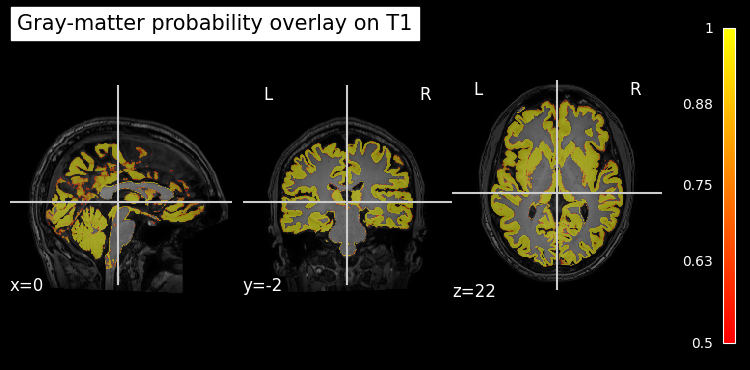

In [18]:
# c1 = gray matter; c2 = white matter; c3 = CSF
gm = next(seg_dir.glob('c1*.nii*'))
print('Gray-matter map:', gm.name)

plotting.plot_roi(
    str(gm),
    bg_img=str(input_t1),
    title='Gray-matter probability overlay on T1',
    display_mode='ortho',
    alpha=0.5,
    cmap='autumn',
    dim=-0.5,
)
plt.show()

If the gray-matter overlay traces the cortical ribbon (thin, follows the gyri/sulci) and avoids skull and background, the segmentation succeeded and the predicted age above is trustworthy.

## Dependencies in Jupyter/Python
- Using the package [watermark](https://github.com/rasbt/watermark) to document system environment and software versions used in this notebook, alongside the Neurodesktop version extracted from the `JUPYTER_IMAGE` or `NEURODESKTOP_VERSION` environment variables.

In [19]:
import os

%load_ext watermark

%watermark
%watermark --iversions

neurodesktop_version = (
    os.environ.get('JUPYTER_IMAGE', '').split(':')[-1] or
    os.environ.get('NEURODESKTOP_VERSION', 'unknown')
)

print(f"Neurodesktop version: {neurodesktop_version}")

Last updated: 2026-05-14T06:18:02.977409+00:00

Python implementation: CPython
Python version       : 3.13.13
IPython version      : 9.12.0

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 5.15.0-177-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 30
Architecture: 64bit

matplotlib: 3.10.9
nibabel   : 5.4.2
nilearn   : 0.13.1
numpy     : 2.4.4
pandas    : 2.3.3

Neurodesktop version: 2026-05-04
